# VA Analysis LangGraph V04

This notebook implements all four planned nodes for the Jenkins failure webhook -> LangGraph remediation workflow:

1. `issue_extraction`
2. `dependency_file_analysis`
3. `validate_and_prepare_changes`
4. `push_changes_to_branch`

It is designed as a prototype that reuses `dev_test/py/non_ai_flow/github_service.py` for repository fetch and branch push behavior.

In [2]:
import os
import re
import sys
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
from pprint import pprint
from typing import Annotated, Literal, Sequence, TypedDict

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain_core.messages import BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph.state import Command, END, START, StateGraph

load_dotenv()
llm_model = os.getenv("LLM_MODEL")
llm = ChatOpenAI(model=llm_model)
print({"llm_model": llm_model})


{'llm_model': 'gpt-5.4-nano'}


In [3]:
class IssueCore(TypedDict):
    issue_category: Literal["VA", "OTHER"]
    detailed_issue: str
    initial_fix: str


class DetailedIssue(TypedDict):
    issue_category: Literal["VA", "OTHER"]
    detailed_issue: str
    initial_fix: str
    bom_friendly_fix: str


class TargetPathHint(TypedDict):
    issue_index: int
    target_file_hint: str


class TargetPathInfo(TypedDict):
    issue_index: int
    target_file_hint: str
    resolved_path: str
    confidence: str


class RepoFile(TypedDict):
    path: str
    content: str


class IssueExtractionResult(TypedDict):
    issue_list: list[IssueCore]
    target_path_hints: list[TargetPathHint]


class BomFixOnly(TypedDict):
    bom_friendly_fix: str


class Node02Result(TypedDict):
    issue_list: list[BomFixOnly]


class FileChangePlan(TypedDict):
    target_file_path: str
    related_issue_indexes: list[int]
    apply_decision: Literal["update_file", "skip", "manual_review"]
    validation_summary: str
    commit_message: str
    updated_content: str


class SingleFileChangeResult(TypedDict):
    apply_decision: Literal["update_file", "skip", "manual_review"]
    validation_summary: str
    commit_message: str
    updated_content: str


class PushResult(TypedDict):
    target_file_path: str
    status: str
    branch_name: str
    compare_url: str
    message: str


class VaAnalysisState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    issue_list: list[DetailedIssue]
    target_path_hints: list[TargetPathHint]
    target_paths: list[TargetPathInfo]
    dependency_files: list[RepoFile]
    file_updates: list[FileChangePlan]
    branch_name: str
    push_results: list[PushResult]


In [ ]:
print(Path.cwd())
jenkins_output_raw_text = Path("trivy_scan_input.txt").read_text(encoding="utf-8")
jenkins_output_raw_text[:2500]


In [4]:
def _collect_message_text(messages: Sequence[BaseMessage]) -> str:
    parts: list[str] = []
    for msg in messages:
        content = getattr(msg, "content", "")
        if isinstance(content, str):
            parts.append(content)
        elif isinstance(content, list):
            for item in content:
                if isinstance(item, str):
                    parts.append(item)
                elif isinstance(item, dict):
                    text = item.get("text")
                    if isinstance(text, str):
                        parts.append(text)
    return "\n".join(parts)


def _extract_file_hints(text: str) -> list[str]:
    patterns = [
        r"(?i)\b[\w./-]*pom\.xml\b",
        r"(?i)\b[\w./-]*build\.gradle(?:\.kts)?\b",
        r"(?i)\b[\w./-]*gradle\.properties\b",
        r"(?i)\b[\w./-]*settings\.gradle(?:\.kts)?\b",
        r"(?i)\b[\w./-]*dockerfile\b",
    ]
    hints: set[str] = set()
    for pattern in patterns:
        for match in re.findall(pattern, text or ""):
            hints.add(match.replace("\\", "/").strip())
    return sorted(hints)


def _get_fetch_analysis_files():
    try:
        from non_ai_flow.github_service import fetch_analysis_files
        return fetch_analysis_files
    except ImportError:
        project_root = Path.cwd().resolve().parents[1]
        py_root = project_root / "dev_test" / "py"
        if str(py_root) not in sys.path:
            sys.path.append(str(py_root))
        from non_ai_flow.github_service import fetch_analysis_files
        return fetch_analysis_files


def _get_push_file_helper():
    try:
        from non_ai_flow.github_service import create_branch_and_push_file
        return create_branch_and_push_file
    except ImportError:
        project_root = Path.cwd().resolve().parents[1]
        py_root = project_root / "dev_test" / "py"
        if str(py_root) not in sys.path:
            sys.path.append(str(py_root))
        from non_ai_flow.github_service import create_branch_and_push_file
        return create_branch_and_push_file


def _filter_relevant_files(files: dict[str, str]) -> list[RepoFile]:
    relevant_files: list[RepoFile] = []
    for path, content in files.items():
        lower = path.lower()
        if (
            lower.endswith("pom.xml")
            or lower.endswith("build.gradle")
            or lower.endswith("build.gradle.kts")
            or lower.endswith("dockerfile")
            or lower.endswith("gradle.properties")
            or lower.endswith("settings.gradle")
            or lower.endswith("settings.gradle.kts")
        ):
            relevant_files.append({"path": path, "content": content})
    return relevant_files


def _score_repo_file(path: str, content: str, hints: list[str], jenkins_text: str) -> int:
    lower_path = path.lower()
    content_lower = content.lower()
    score = 0

    for hint in hints:
        hint_lower = hint.lower()
        if lower_path == hint_lower:
            score += 100
        elif lower_path.endswith(hint_lower):
            score += 60
        elif hint_lower in lower_path:
            score += 30

    if "pom.xml" in jenkins_text.lower() and lower_path.endswith("pom.xml"):
        score += 15
    if "build.gradle" in jenkins_text.lower() and "build.gradle" in lower_path:
        score += 15
    if "dockerfile" in jenkins_text.lower() and lower_path.endswith("dockerfile"):
        score += 15

    depth = lower_path.count("/")
    score += max(0, 10 - depth)

    if lower_path.endswith("pom.xml"):
        if "<dependencymanagement>" in content_lower:
            score += 20
        if "<parent>" in content_lower:
            score += 15

    if lower_path.endswith(("build.gradle", "build.gradle.kts")):
        if "platform(" in content_lower or "enforcedplatform(" in content_lower:
            score += 20
        if "dependencymanagement" in content_lower:
            score += 15

    return score


def _resolve_target_paths(
    issue_count: int,
    target_path_hints: list[TargetPathHint],
    relevant_files: list[RepoFile],
    jenkins_text: str,
) -> list[TargetPathInfo]:
    paths: list[TargetPathInfo] = []
    if not relevant_files:
        for idx in range(issue_count):
            paths.append({
                "issue_index": idx,
                "target_file_hint": "",
                "resolved_path": "",
                "confidence": "low",
            })
        return paths

    hint_map = {item["issue_index"]: item["target_file_hint"] for item in target_path_hints}
    all_hints = _extract_file_hints(jenkins_text)

    for idx in range(issue_count):
        hint = hint_map.get(idx, "")
        candidate_hints = [hint] if hint else []
        candidate_hints.extend(all_hints)
        ranked = sorted(
            relevant_files,
            key=lambda item: _score_repo_file(item["path"], item["content"], candidate_hints, jenkins_text),
            reverse=True,
        )
        best = ranked[0]
        best_score = _score_repo_file(best["path"], best["content"], candidate_hints, jenkins_text)
        confidence = "high" if best_score >= 90 else "medium" if best_score >= 40 else "low"
        paths.append({
            "issue_index": idx,
            "target_file_hint": hint,
            "resolved_path": best["path"],
            "confidence": confidence,
        })
    return paths


def _build_branch_name(issue_list: list[DetailedIssue], prefix: str = "ai-va-fix") -> str:
    issue_part = "dependency"
    for issue in issue_list:
        detail = issue.get("detailed_issue", "")
        if detail:
            token = re.sub(r"[^a-z0-9-]+", "-", detail.lower())
            token = re.sub(r"-+", "-", token).strip("-")
            if token:
                issue_part = token[:30]
                break
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%d%H%M%S")
    return f"{prefix}/{issue_part}-{timestamp}"


In [5]:
# NODE 01 -> fetch and analyze all issues
# Updates issue_category, detailed_issue, initial_fix
# Also stores target path hints for Node 02

def issue_extraction(state: VaAnalysisState):
    issue_extraction_agent_system_prompt = """
    You are Node 01 in a LangGraph vulnerability remediation workflow.

    Responsibilities:
    1. Read the Jenkins / Trivy scan output.
    2. Extract all issues.
    3. Flag each issue as VA or OTHER.
    4. Produce a detailed issue description.
    5. Produce an initial fix.
    6. Provide a target_file_hint for each issue when possible.

    Rules:
    - Do not produce bom_friendly_fix here.
    - Use zero-based issue_index values in target_path_hints.
    - If many issues come from the same target, repeat the same hint for each issue.
    """

    issue_extraction_agent = create_agent(
        model=llm,
        response_format=IssueExtractionResult,
        system_prompt=issue_extraction_agent_system_prompt,
    )

    issue_extraction_agent_response = issue_extraction_agent.invoke({
        "messages": state["messages"]
    })

    core_issues = issue_extraction_agent_response["structured_response"]["issue_list"]
    hint_items = issue_extraction_agent_response["structured_response"].get("target_path_hints", [])

    full_issues: list[DetailedIssue] = [
        {
            "issue_category": issue["issue_category"],
            "detailed_issue": issue["detailed_issue"],
            "initial_fix": issue["initial_fix"],
            "bom_friendly_fix": "",
        }
        for issue in core_issues
    ]

    if not hint_items:
        jenkins_text = _collect_message_text(state["messages"])
        fallback_hints = _extract_file_hints(jenkins_text)
        if fallback_hints:
            hint_items = [
                {
                    "issue_index": idx,
                    "target_file_hint": fallback_hints[0],
                }
                for idx in range(len(full_issues))
            ]

    return Command(update={
        "issue_list": full_issues,
        "target_path_hints": hint_items,
    })


In [6]:
# NODE 02 -> fetch dependency/container files and update only bom_friendly_fix
# Uses dev_test/py/non_ai_flow/github_service.py

def dependency_file_analysis(state: VaAnalysisState, config=None):
    configurable = (config or {}).get("configurable", {})
    repo_name = configurable.get("repo_name")
    branch_name = configurable.get("branch_name", "main")
    mock_files = configurable.get("mock_files")
    existing_issues = state.get("issue_list", [])
    target_path_hints = state.get("target_path_hints", [])
    jenkins_text = _collect_message_text(state.get("messages", []))

    if mock_files:
        files = mock_files
    else:
        if not repo_name:
            return Command(update={
                "issue_list": [
                    {
                        **issue,
                        "bom_friendly_fix": issue.get("bom_friendly_fix", "") or (
                            "Node 02 skipped because repo_name was not provided in config."
                        ),
                    }
                    for issue in existing_issues
                ],
                "target_paths": [],
                "dependency_files": [],
            })

        fetch_analysis_files = _get_fetch_analysis_files()
        files = fetch_analysis_files(repo_name, branch_name)

    relevant_files = _filter_relevant_files(files)
    resolved_target_paths = _resolve_target_paths(
        issue_count=len(existing_issues),
        target_path_hints=target_path_hints,
        relevant_files=relevant_files,
        jenkins_text=jenkins_text,
    )

    selected_paths = []
    for item in resolved_target_paths:
        if item["resolved_path"] and item["resolved_path"] not in selected_paths:
            selected_paths.append(item["resolved_path"])

    selected_files = [item for item in relevant_files if item["path"] in selected_paths]
    if not selected_files:
        selected_files = relevant_files[:5]

    issue_lines = []
    for idx, issue in enumerate(existing_issues, start=1):
        issue_lines.append(
            f"Issue {idx}\n"
            f"- issue_category: {issue.get('issue_category', '')}\n"
            f"- detailed_issue: {issue.get('detailed_issue', '')}\n"
            f"- initial_fix: {issue.get('initial_fix', '')}\n"
            f"- current_bom_friendly_fix: {issue.get('bom_friendly_fix', '')}"
        )

    target_path_lines = []
    for item in resolved_target_paths:
        target_path_lines.append(
            f"- issue_index={item['issue_index']}, hint={item['target_file_hint']}, "
            f"resolved_path={item['resolved_path']}, confidence={item['confidence']}"
        )

    file_lines = []
    for item in selected_files:
        preview = item["content"][:8000]
        file_lines.append(f"### FILE: {item['path']}\n{preview}")

    node02_prompt = f"""
You are Node 02 in a LangGraph vulnerability remediation workflow.

Task:
Review the extracted issues and the selected repository dependency/container files.
For each issue, improve ONLY the `bom_friendly_fix` field.

Rules:
1. Do not change issue_category.
2. Do not change detailed_issue.
3. Do not change initial_fix.
4. Update ONLY bom_friendly_fix.
5. Make the fix BOM-friendly and non-conflicting.
6. Prefer a single source of truth:
   - Spring Boot parent/BOM
   - Maven dependencyManagement
   - Gradle platform/version catalog/property
   - Docker base image strategy if relevant
7. Avoid scattered direct overrides when a parent/BOM/platform controls the version.
8. Keep output aligned issue-for-issue with the input order.
9. Use the resolved target paths as the most likely relevant files for this Jenkins response.

Resolved target paths:
{chr(10).join(target_path_lines) if target_path_lines else '- No resolved target paths.'}

Issues:
{chr(10).join(issue_lines) if issue_lines else '- No issues provided.'}

Most relevant dependency/container files:
{chr(10).join(file_lines) if file_lines else '- No dependency files found.'}

Return only a structured issue_list where each item contains:
- bom_friendly_fix
"""

    node02_agent = create_agent(
        model=llm,
        response_format=Node02Result,
        system_prompt=(
            "You improve only the bom_friendly_fix field for each issue, using "
            "dependency files to produce BOM-friendly, non-conflicting guidance."
        ),
    )

    node02_response = node02_agent.invoke({
        "messages": [HumanMessage(content=node02_prompt)]
    })

    updated_fix_items = node02_response["structured_response"]["issue_list"]

    merged_issue_list: list[DetailedIssue] = []
    for idx, issue in enumerate(existing_issues):
        new_fix = issue.get("bom_friendly_fix", "")
        if idx < len(updated_fix_items):
            new_fix = updated_fix_items[idx].get("bom_friendly_fix", new_fix)
        merged_issue_list.append({
            **issue,
            "bom_friendly_fix": new_fix,
        })

    return Command(update={
        "issue_list": merged_issue_list,
        "target_paths": resolved_target_paths,
        "dependency_files": relevant_files,
    })


In [7]:
# NODE 03 -> validate selected files and generate concrete file updates
# Groups issues by resolved file path and prepares one non-conflicting change per file.

def validate_and_prepare_changes(state: VaAnalysisState):
    issue_list = state.get("issue_list", [])
    target_paths = state.get("target_paths", [])
    dependency_files = state.get("dependency_files", [])
    file_map = {item["path"]: item["content"] for item in dependency_files}

    issues_by_path: dict[str, list[tuple[int, DetailedIssue]]] = defaultdict(list)
    for target in target_paths:
        idx = target["issue_index"]
        resolved_path = target.get("resolved_path", "")
        if resolved_path and idx < len(issue_list):
            issues_by_path[resolved_path].append((idx, issue_list[idx]))

    file_updates: list[FileChangePlan] = []

    for target_file_path, indexed_issues in issues_by_path.items():
        current_content = file_map.get(target_file_path, "")
        if not current_content:
            file_updates.append({
                "target_file_path": target_file_path,
                "related_issue_indexes": [idx for idx, _ in indexed_issues],
                "apply_decision": "manual_review",
                "validation_summary": "Current file content was not available for validation and patch preparation.",
                "commit_message": f"Review vulnerability remediation for {target_file_path}",
                "updated_content": "",
            })
            continue

        issue_lines = []
        for idx, issue in indexed_issues:
            issue_lines.append(
                f"Issue index: {idx}\n"
                f"- issue_category: {issue['issue_category']}\n"
                f"- detailed_issue: {issue['detailed_issue']}\n"
                f"- initial_fix: {issue['initial_fix']}\n"
                f"- bom_friendly_fix: {issue['bom_friendly_fix']}"
            )

        node03_prompt = f"""
You are Node 03 in a LangGraph vulnerability remediation workflow.

Task:
Validate the chosen file and prepare a single safe file update.

Target file path:
{target_file_path}

Related issues:
{chr(10).join(issue_lines)}

Current file content:
{current_content[:16000]}

Rules:
1. Respect BOM or platform ownership of versions.
2. Produce one non-conflicting combined update for the whole file.
3. If a safe automatic update is not possible, return manual_review.
4. If no change is needed, return skip.
5. If apply_decision is update_file, return the full updated file content.
6. Keep the file syntactically valid.
7. The commit_message should be concise and file-specific.
"""

        node03_agent = create_agent(
            model=llm,
            response_format=SingleFileChangeResult,
            system_prompt=(
                "You validate BOM-friendly remediation plans and prepare safe file-level updates."
            ),
        )

        node03_response = node03_agent.invoke({
            "messages": [HumanMessage(content=node03_prompt)]
        })
        change = node03_response["structured_response"]
        file_updates.append({
            "target_file_path": target_file_path,
            "related_issue_indexes": [idx for idx, _ in indexed_issues],
            "apply_decision": change["apply_decision"],
            "validation_summary": change["validation_summary"],
            "commit_message": change["commit_message"],
            "updated_content": change["updated_content"],
        })

    return Command(update={
        "file_updates": file_updates,
    })


In [8]:
# NODE 04 -> push the new changes to a new branch
# Reuses the non-AI flow helper in github_service.py.
# For safe testing, use configurable.mock_push=True.

def push_changes_to_branch(state: VaAnalysisState, config=None):
    configurable = (config or {}).get("configurable", {})
    repo_name = configurable.get("repo_name")
    base_branch = configurable.get("base_branch") or configurable.get("branch_name") or "main"
    mock_push = configurable.get("mock_push", True)
    new_branch = configurable.get("new_branch") or state.get("branch_name") or _build_branch_name(state.get("issue_list", []))

    file_updates = state.get("file_updates", [])
    eligible_updates = [item for item in file_updates if item.get("apply_decision") == "update_file" and item.get("updated_content")]

    if not eligible_updates:
        return Command(update={
            "branch_name": new_branch,
            "push_results": [{
                "target_file_path": "",
                "status": "skipped",
                "branch_name": new_branch,
                "compare_url": "",
                "message": "No eligible file updates were available for push.",
            }],
        })

    if mock_push or not repo_name:
        return Command(update={
            "branch_name": new_branch,
            "push_results": [
                {
                    "target_file_path": item["target_file_path"],
                    "status": "dry-run",
                    "branch_name": new_branch,
                    "compare_url": "",
                    "message": item["commit_message"],
                }
                for item in eligible_updates
            ],
        })

    create_branch_and_push_file = _get_push_file_helper()
    push_results: list[PushResult] = []

    for item in eligible_updates:
        push_result = create_branch_and_push_file(
            repo_name=repo_name,
            base_branch=base_branch,
            new_branch=new_branch,
            target_file=item["target_file_path"],
            updated_content=item["updated_content"],
            commit_message=item["commit_message"],
        )
        push_results.append({
            "target_file_path": push_result.get("target_file", item["target_file_path"]),
            "status": push_result.get("status", "pushed"),
            "branch_name": push_result.get("branch_name", new_branch),
            "compare_url": push_result.get("compare_url", ""),
            "message": item["commit_message"],
        })

    return Command(update={
        "branch_name": new_branch,
        "push_results": push_results,
    })


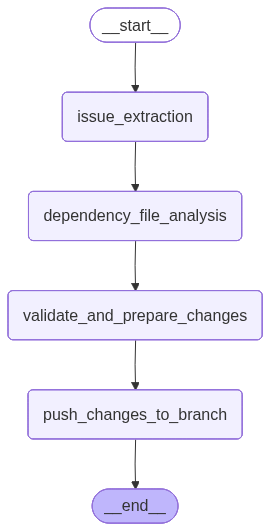

In [11]:
# Graph setup

graph = StateGraph(VaAnalysisState)

graph.add_node("issue_extraction", issue_extraction)
graph.add_node("dependency_file_analysis", dependency_file_analysis)
graph.add_node("validate_and_prepare_changes", validate_and_prepare_changes)
graph.add_node("push_changes_to_branch", push_changes_to_branch)

graph.add_edge(START, "issue_extraction")
graph.add_edge("issue_extraction", "dependency_file_analysis")
graph.add_edge("dependency_file_analysis", "validate_and_prepare_changes")
graph.add_edge("validate_and_prepare_changes", "push_changes_to_branch")
graph.add_edge("push_changes_to_branch", END)

compiled_graph = graph.compile()
compiled_graph


## Ways To Test Properly

Recommended order:

1. Run the setup, schema, helper, and graph cells.
2. Run the offline end-to-end test first with `mock_files` and `mock_push=True`.
3. Inspect `issue_list`, `target_paths`, `file_updates`, and `push_results`.
4. Run the real repository analysis test with `repo_name` and `branch_name`, but keep `mock_push=True`.
5. Only after reviewing the proposed file updates should you run the real push test with `mock_push=False`.

Validation checklist:

- Node 01 extracted all expected issues from the Jenkins/Trivy output.
- Node 02 picked the correct `pom.xml`, `build.gradle`, or `Dockerfile`.
- Node 03 merged multiple issue fixes into a single coherent file update per path.
- Node 04 generated one shared branch and one push record per updated file.
- For dry runs, nothing is written to GitHub.
- For real pushes, verify the generated compare URL and the file content in the branch before opening a PR manually if needed.

In [15]:
print(Path.cwd())
jenkins_output_raw_text = Path("trivy_scan_input.txt").read_text(encoding="utf-8")
jenkins_output_raw_text[:2000]


d:\DIALOG\DESKTOP\AI -Products\Project 07 - Automated vulnerability detection and remediation for CICD pipelines\PROPER_CODE_BASE\pipeline-security-autofix\dev_test\notebook


"===== build-image.log =====\n\n\n===== scan-dependencies.log =====\n\nReport Summary\n\n┌─────────┬──────┬─────────────────┐\n│ Target  │ Type │ Vulnerabilities │\n├─────────┼──────┼─────────────────┤\n│ pom.xml │ pom  │       30        │\n└─────────┴──────┴─────────────────┘\nLegend:\n- '-': Not scanned\n- '0': Clean (no security findings detected)\n\n\nFor OSS Maintainers: VEX Notice\n--------------------------------\nIf you're an OSS maintainer and Trivy has detected vulnerabilities in your project that you believe are not actually exploitable, consider issuing a VEX (Vulnerability Exploitability eXchange) statement.\nVEX allows you to communicate the actual status of vulnerabilities in your project, improving security transparency and reducing false positives for your users.\nLearn more and start using VEX: https://trivy.dev/docs/v0.70/guide/supply-chain/vex/repo#publishing-vex-documents\n\nTo disable this notice, set the TRIVY_DISABLE_VEX_NOTICE environment variable.\n\n\npom.xml

In [13]:
# Test 1: Offline end-to-end test
mock_files = {
    "pom.xml": """
<project>
  <parent>
    <groupId>org.springframework.boot</groupId>
    <artifactId>spring-boot-starter-parent</artifactId>
    <version>2.7.18</version>
  </parent>
  <dependencies>
    <dependency>
      <groupId>org.springframework.boot</groupId>
      <artifactId>spring-boot-starter-web</artifactId>
    </dependency>
  </dependencies>
</project>
""",
    "service-a/pom.xml": """
<project>
  <dependencies>
    <dependency>
      <groupId>org.apache.logging.log4j</groupId>
      <artifactId>log4j-core</artifactId>
      <version>2.14.1</version>
    </dependency>
  </dependencies>
</project>
""",
    "Dockerfile": """
FROM eclipse-temurin:17-jre
RUN echo hello
""",
}

mock_results = compiled_graph.invoke(
    {
        "messages": [HumanMessage(content=jenkins_output_raw_text)],
        "issue_list": [],
        "target_path_hints": [],
        "target_paths": [],
        "dependency_files": [],
        "file_updates": [],
        "branch_name": "",
        "push_results": [],
    },
    config={
        "configurable": {
            "mock_files": mock_files,
            "mock_push": True,
        }
    },
)

print("\nResolved target paths")
pprint(mock_results["target_paths"])
print("\nIssues")
pprint(mock_results["issue_list"][:3])
print("\nPrepared file updates")
pprint(mock_results["file_updates"])
print("\nPush results")
pprint(mock_results["push_results"])


NameError: name 'jenkins_output_raw_text' is not defined

In [ ]:
# Test 2: Real repo analysis with dry-run push
# Replace owner/repo and branch before running.


real_results = compiled_graph.invoke(
    {
        "messages": [HumanMessage(content=jenkins_output_raw_text)],
        "issue_list": [],
        "target_path_hints": [],
        "target_paths": [],
        "dependency_files": [],
        "file_updates": [],
        "branch_name": "",
        "push_results": [],
    },
    config={
        "configurable": {
            "repo_name": "nishathmnha/demo-springboot-vuln-service",
            "branch_name": "main",
            "base_branch": "main",
            "mock_push": True,
        }
    },
)

print("\nResolved target paths")
pprint(real_results["target_paths"])
print("\nPrepared file updates")
pprint(real_results["file_updates"])
print("\nDry-run push results")
pprint(real_results["push_results"])



Resolved target paths
[{'confidence': 'high',
  'issue_index': 0,
  'resolved_path': 'jenkins-webhook-and-github-setup/demo-springboot-vuln-service/pom.xml',
  'target_file_hint': 'pom.xml (set/override property or dependency version '
                      'for ch.qos.logback:logback-classic to >= '
                      '1.3.12/1.4.12/1.2.13)'},
 {'confidence': 'high',
  'issue_index': 1,
  'resolved_path': 'jenkins-webhook-and-github-setup/demo-springboot-vuln-service/pom.xml',
  'target_file_hint': 'pom.xml (set/override dependency version for '
                      'ch.qos.logback:logback-core to >= '
                      '1.4.14/1.3.14/1.2.13)'},
 {'confidence': 'high',
  'issue_index': 2,
  'resolved_path': 'jenkins-webhook-and-github-setup/demo-springboot-vuln-service/pom.xml',
  'target_file_hint': 'pom.xml (set/override '
                      'com.fasterxml.jackson.core:jackson-core to 2.15.0 or '
                      'newer)'},
 {'confidence': 'high',
  'issue_index': 3

In [20]:
print("\nPrepared file updates")
pprint(real_results["file_updates"])


Prepared file updates
[{'apply_decision': 'manual_review',
  'commit_message': 'manual_review: cannot safely remediate all referenced '
                    'CVEs with a single coordinated POM update',
  'related_issue_indexes': [0,
                            1,
                            2,
                            3,
                            4,
                            5,
                            6,
                            7,
                            8,
                            9,
                            10,
                            11,
                            12,
                            13,
                            14,
                            15,
                            16,
                            17,
                            18,
                            19,
                            20,
                            21,
                            22,
                            23,
                            24,
        

In [ ]:
# Test 3: Real push to a new branch
# Run this only after reviewing the dry-run output and verifying your GitHub token configuration.

push_results = compiled_graph.invoke(
    {
        "messages": [HumanMessage(content=jenkins_output_raw_text)],
        "issue_list": [],
        "target_path_hints": [],
        "target_paths": [],
        "dependency_files": [],
        "file_updates": [],
        "branch_name": "",
        "push_results": [],
    },
    config={
        "configurable": {
            "repo_name": "owner/repo",
            "branch_name": "main",
            "base_branch": "main",
            "mock_push": False,
        }
    },
)

print("\nBranch name")
print(push_results["branch_name"])
print("\nPush results")
pprint(push_results["push_results"])
